In [1]:
import tensorflow as tf
import pathlib
import os
import pandas as pd
import numpy as np
import cv2
import random
from diffusers import StableDiffusionPipeline
import torch
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# base path to your dataset
base_path = "6 Emotions for image classification"

data = []

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if not os.path.isdir(folder_path):
        continue

    for img_file in os.listdir(folder_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, img_file)
            data.append([img_path, folder])

df = pd.DataFrame(data, columns=['image_path', 'emotion'])

print("✅ Loaded images:", len(df))
print("✅ Classes found:", df['emotion'].unique())

✅ Loaded images: 1146
✅ Classes found: ['anger' 'disgust' 'fear' 'happy' 'pain' 'sad']


In [3]:
# encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['emotion'])
print("✅ Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# split test training set
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

✅ Label mapping: {'anger': np.int64(0), 'disgust': np.int64(1), 'fear': np.int64(2), 'happy': np.int64(3), 'pain': np.int64(4), 'sad': np.int64(5)}
Train: 916, Val: 115, Test: 115


In [4]:
# resize the image
IMAGE_SIZE = (224, 224)

def load_and_preprocess(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)
    img = img.astype("float32") / 255.0   # normalization to 0 - 1
    return img

# load image arrays
cnn_X_train, cnn_y_train = [], []
cnn_X_val, cnn_y_val = [], []
cnn_X_test, cnn_y_test = [], []

# training set
for _, row in train_df.iterrows():
    img = load_and_preprocess(row['image_path'])
    if img is not None:
        cnn_X_train.append(img)
        cnn_y_train.append(row['label'])

# validation set
for _, row in val_df.iterrows():
    img = load_and_preprocess(row['image_path'])
    if img is not None:
        cnn_X_val.append(img)
        cnn_y_val.append(row['label'])

# test set
for _, row in test_df.iterrows():
    img = load_and_preprocess(row['image_path'])
    if img is not None:
        cnn_X_test.append(img)
        cnn_y_test.append(row['label'])

# convert to numpy arrays
cnn_X_train = np.array(cnn_X_train)
cnn_X_val = np.array(cnn_X_val)
cnn_X_test = np.array(cnn_X_test)

cnn_y_train = to_categorical(cnn_y_train)
cnn_y_val = to_categorical(cnn_y_val)
cnn_y_test = to_categorical(cnn_y_test)

print("✅ CNN data shapes:")
print("Train:", cnn_X_train.shape, cnn_y_train.shape)
print("Val:", cnn_X_val.shape, cnn_y_val.shape)
print("Test:", cnn_X_test.shape, cnn_y_test.shape)

# label decoding (for visualization
emotion_labels = le.inverse_transform(np.arange(len(le.classes_)))

print("\nAll classes:", emotion_labels)

✅ CNN data shapes:
Train: (710, 224, 224, 3) (710, 6)
Val: (89, 224, 224, 3) (89, 6)
Test: (92, 224, 224, 3) (92, 6)

All classes: ['anger' 'disgust' 'fear' 'happy' 'pain' 'sad']


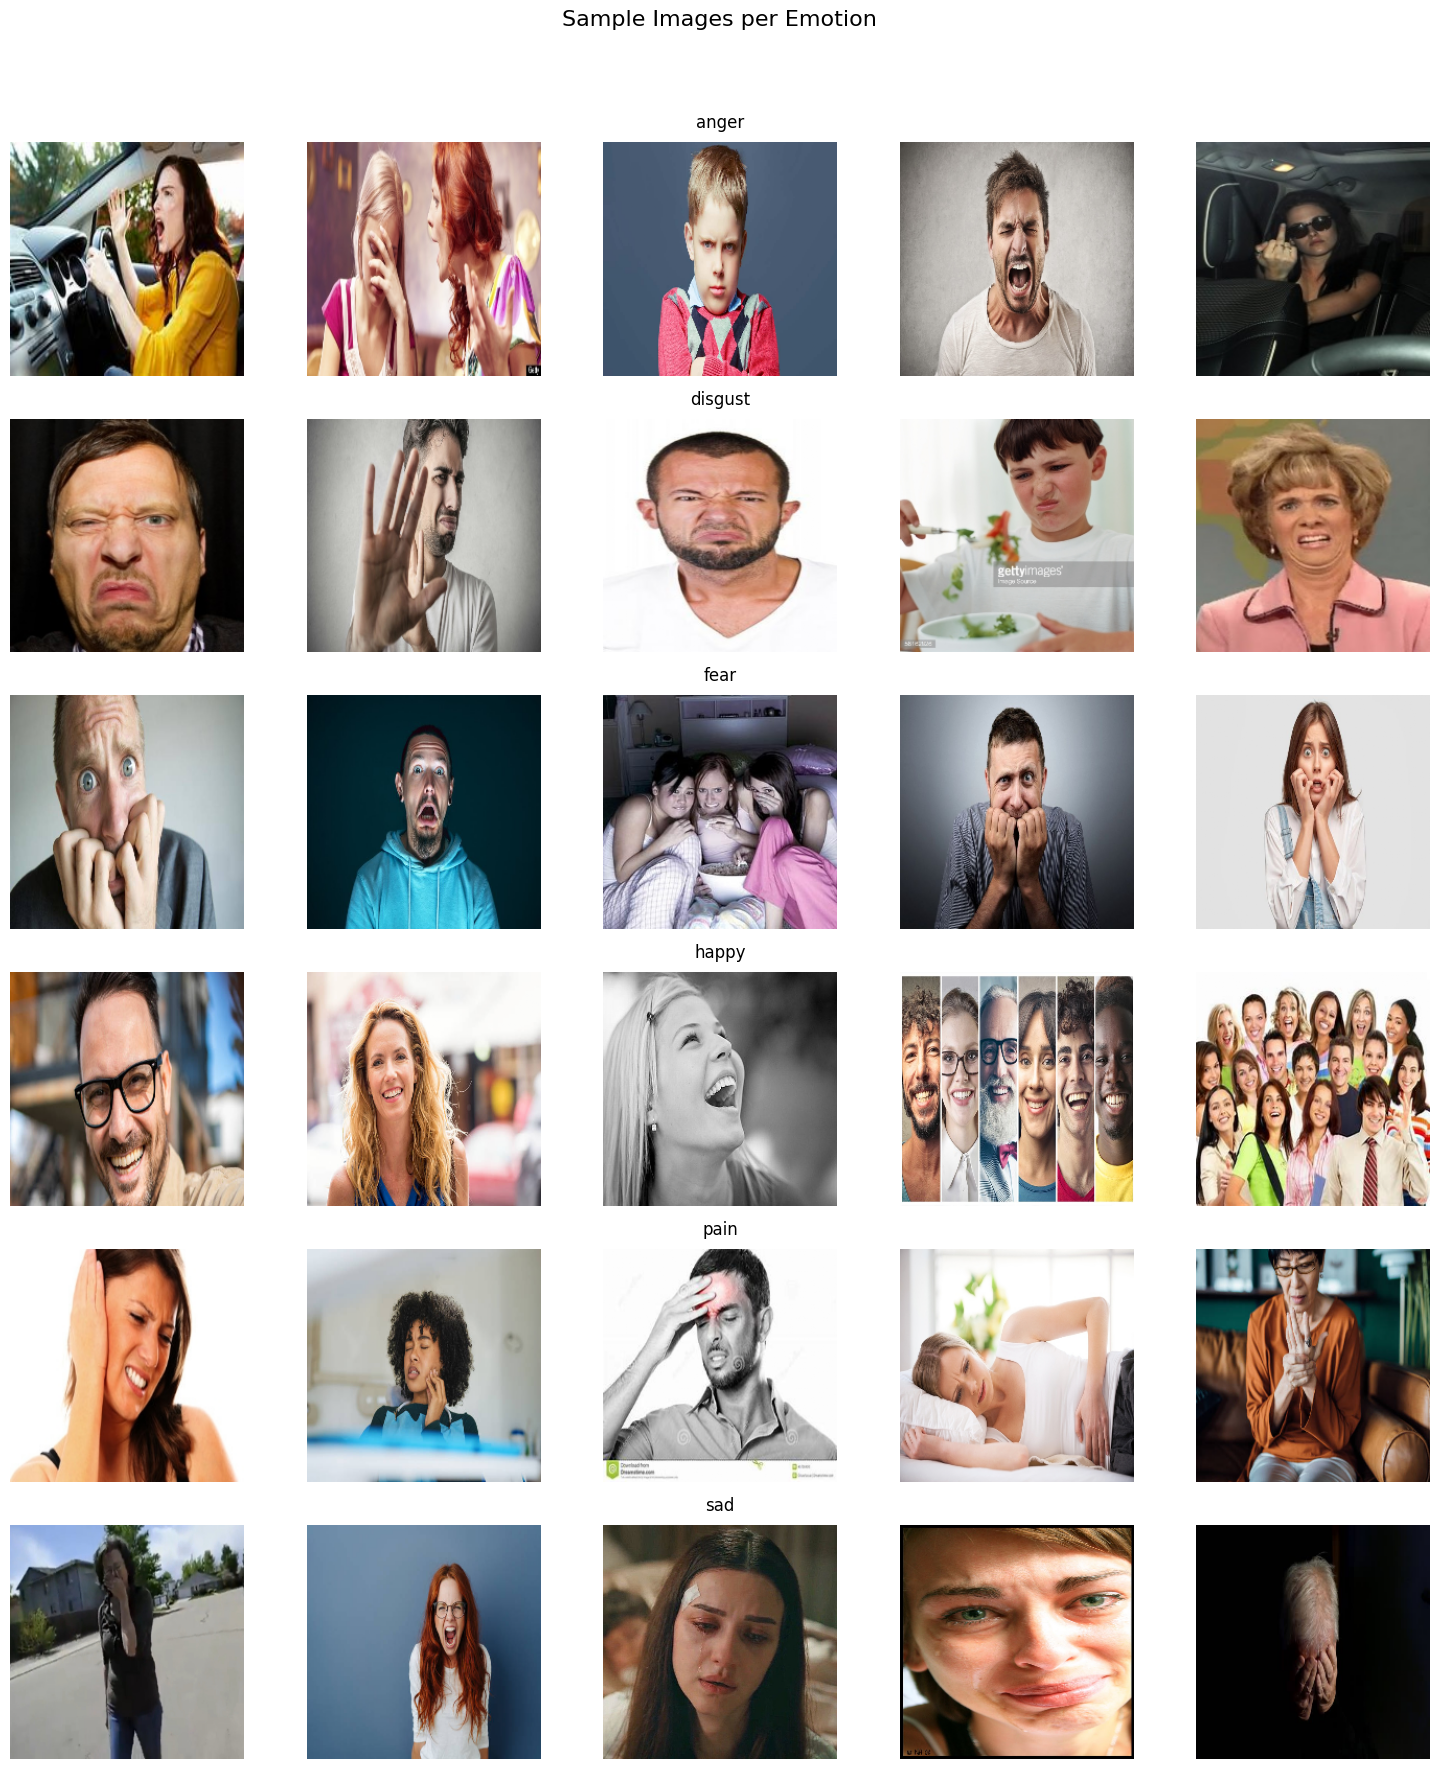

In [5]:
# label name
emotion_labels = le.inverse_transform(np.arange(len(le.classes_)))

plt.figure(figsize=(15, len(emotion_labels) * 3))
plt.suptitle("Sample Images per Emotion", fontsize=16)

# loop each emotion label
for i, label in enumerate(emotion_labels):
    # find indices of this class
    indices = np.where(np.argmax(cnn_y_train, axis=1) == i)[0]
    
    # show 5 random samples
    selected = random.sample(list(indices), min(5, len(indices)))
    
    # show label image in row
    for j, idx in enumerate(selected):
        plt.subplot(len(emotion_labels), 5, i * 5 + j + 1)
        plt.imshow(cnn_X_train[idx])
        plt.axis("off")
        
        # show label on the middle top
        if j == 2:  # middle column (3rd image)
            plt.title(label, fontsize=12, pad=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

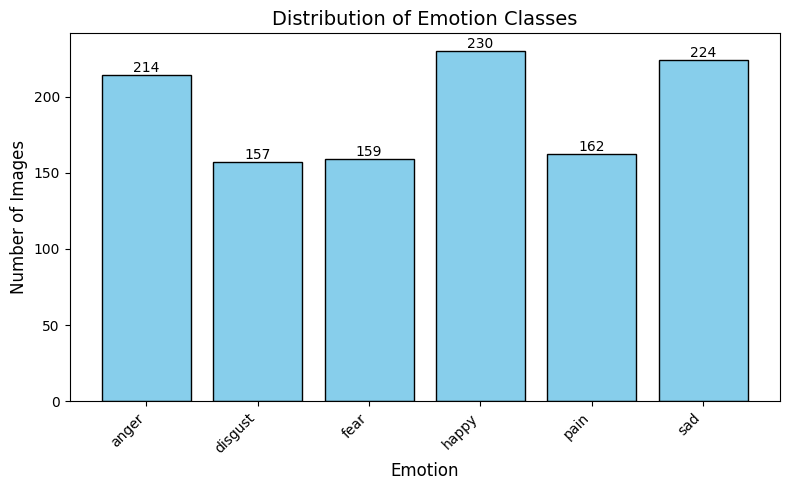

In [6]:
# count how many images per label
emotion_counts = df['emotion'].value_counts().sort_index()

# load images
emotions = emotion_counts.index
counts = emotion_counts.values

plt.figure(figsize=(8, 5))
plt.bar(emotions, counts, color='skyblue', edgecolor='black')

# labels and title
plt.title("Distribution of Emotion Classes", fontsize=14)
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

# Rotate x-labels if long
plt.xticks(rotation=45, ha='right')

# show value on bar
for i, count in enumerate(counts):
    plt.text(i, count + 2, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
# model training libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Average, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# number of emotion categories
num_classes = cnn_y_train.shape[1]

cnn_model = Sequential([
    # layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),
    BatchNormalization(),

    # layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),

    # layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.4),

    Flatten(),

    # fully connected layers
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.summary()

Model: "sequential"


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │

 Total params: 11,169,862 (42.61 MB)


 Trainable params: 11,169,798 (42.61 MB)


 Non-trainable params: 64 (256.00 B)


In [18]:
# compile model and adjust learning rate
cnn_model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# early stop while overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# learning rate adjust while training
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# data augmentation reduce loses
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(cnn_X_train)

history = cnn_model.fit(
    cnn_X_train, cnn_y_train,
    epochs=50,
    batch_size=32,
    validation_data=(cnn_X_val, cnn_y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - accuracy: 0.2070 - loss: 1.9864 - val_accuracy: 0.1685 - val_loss: 1.7892 - learning_rate: 5.0000e-05
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - accuracy: 0.2197 - loss: 1.7602 - val_accuracy: 0.1573 - val_loss: 1.7876 - learning_rate: 5.0000e-05
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 710ms/step - accuracy: 0.2225 - loss: 1.7304 - val_accuracy: 0.1573 - val_loss: 1.7864 - learning_rate: 5.0000e-05
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.2268 - loss: 1.7386 - val_accuracy: 0.1798 - val_loss: 1.7819 - learning_rate: 5.0000e-05
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.2451 - loss: 1.7230 - val_accuracy: 0.2472 - val_loss: 1.7755 - learning_rate: 5.0000e-05
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 478ms/step - accuracy: 0.2394 - loss: 1.7068 - val_accuracy: 0.1573 - val_loss: 1.7756 - learning_rate: 5.0000e-05
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 443ms/step - accurac

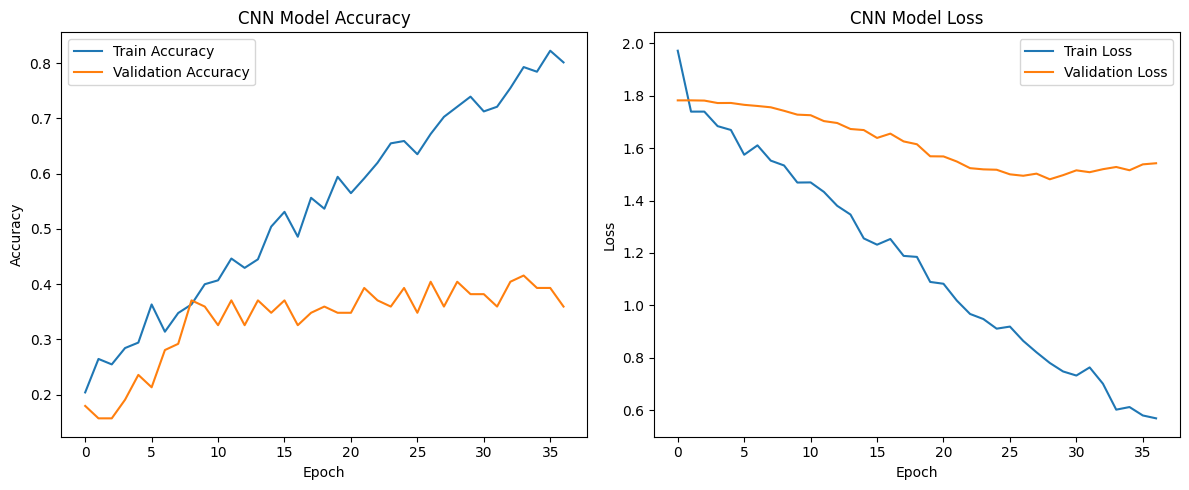

In [ ]:
plt.figure(figsize=(12,5))

# accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
test_loss, test_acc = cnn_model.evaluate(cnn_X_test, cnn_y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

✅ Test Accuracy: 25.00%


In [21]:
# transfer learning data
# parameters identify
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = len(le.classes_)  # 6 labels (emotions)
EPOCHS = 30

# image augmentation
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# normalize validation data
val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(cnn_X_train, cnn_y_train, batch_size=BATCH_SIZE)
val_generator = val_datagen.flow(cnn_X_val, cnn_y_val, batch_size=BATCH_SIZE)

# pretrained model call (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze base layers initially
for layer in base_model.layers:
    layer.trainable = False

# custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
preds = Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=preds)

# compile model
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# learning rate adjust
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

# fine-tuning
# unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

# recompile with lower learning rate
transfer_model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# continue training
history_fine = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

Epoch 1/30


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.1901 - loss: 2.1802 - val_accuracy: 0.2921 - val_loss: 1.7318 - learning_rate: 1.0000e-04
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 268ms/step - accuracy: 0.2901 - loss: 1.7959 - val_accuracy: 0.4270 - val_loss: 1.5362 - learning_rate: 1.0000e-04
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.3394 - loss: 1.7015 - val_accuracy: 0.4719 - val_loss: 1.4804 - learning_rate: 1.0000e-04
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 272ms/step - accuracy: 0.4014 - loss: 1.5441 - val_accuracy: 0.4944 - val_loss: 1.4305 - learning_rate: 1.0000e-04
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 497ms/step - accuracy: 0.4225 - loss: 1.5026 - val_accuracy: 0.5393 - val_loss: 1.3660 - learning_rate: 1.0000e-04
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 37s 403ms/step - accuracy: 0.4549 - loss: 1.4310 - val_accuracy: 0.5506 - val_loss: 1.3297 - learning_rate: 1.0000e-04
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.4817 - 

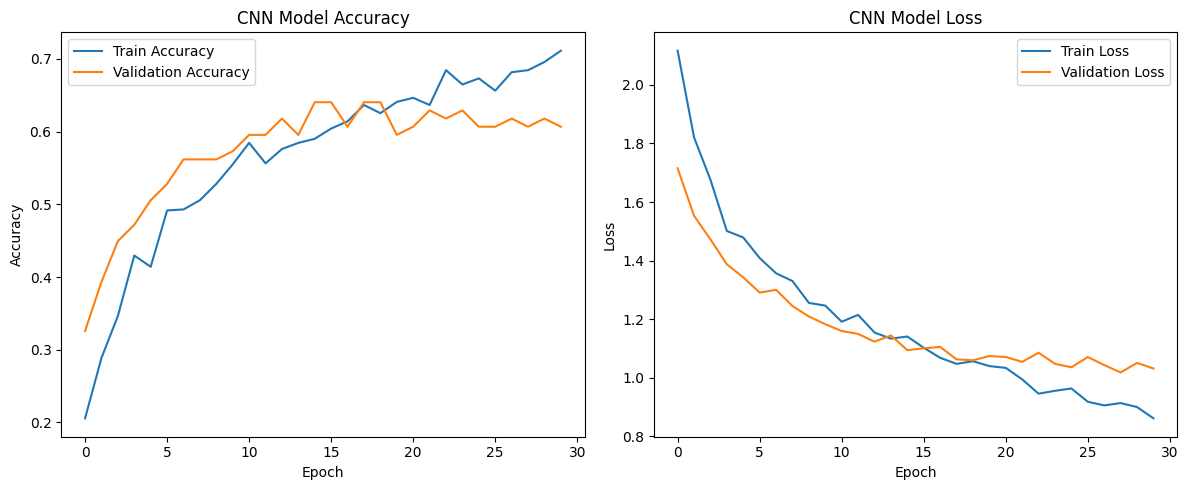

In [ ]:
plt.figure(figsize=(12,5))

# accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step


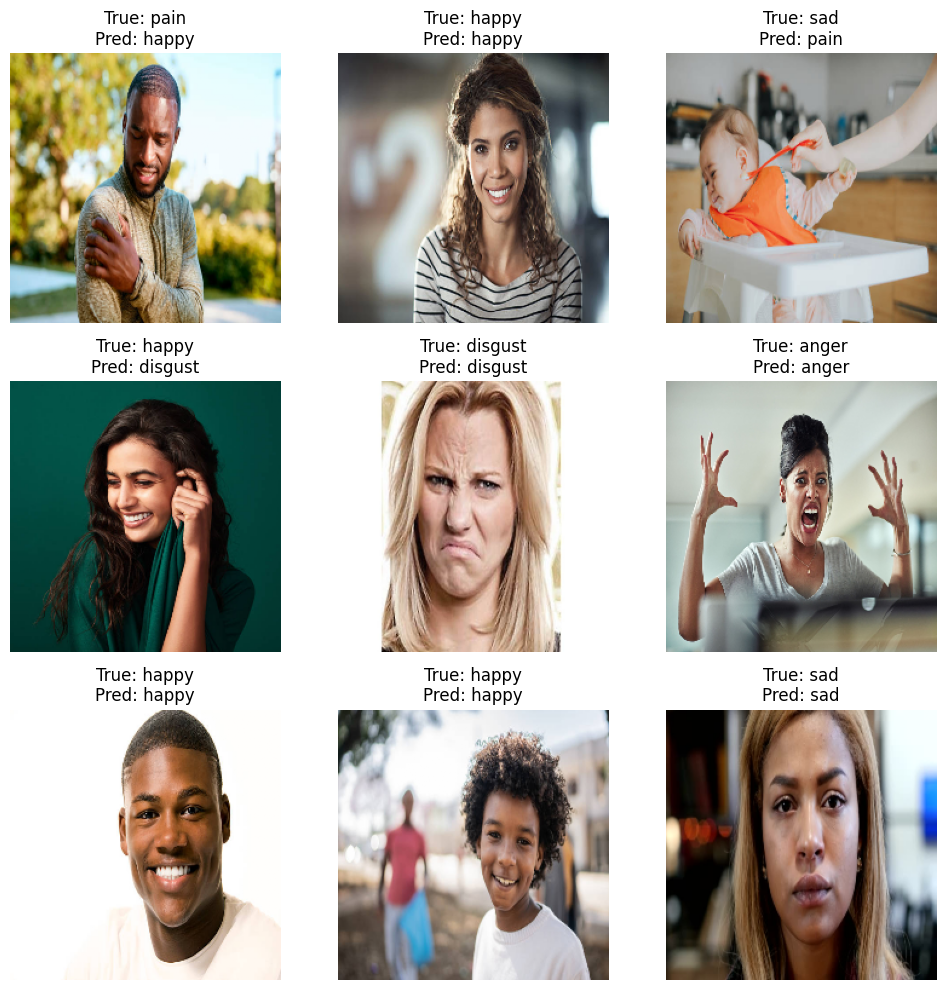

In [22]:
# predict labels using train data (transfer learning model)
y_pred_probs = transfer_model.predict(cnn_X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(cnn_y_test, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(cnn_X_test[i])
    plt.title(f"True: {emotion_labels[y_true[i]]}\nPred: {emotion_labels[y_pred[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


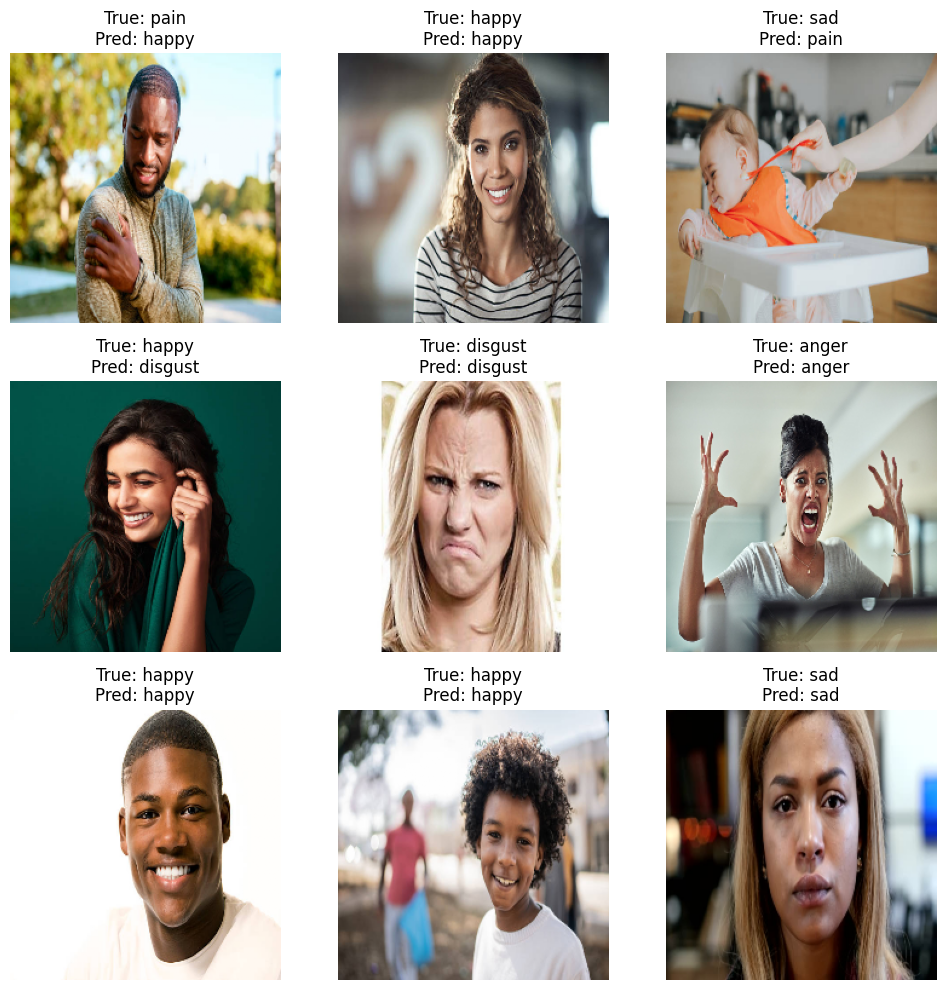

In [23]:
# predict classes using train data (customize cnn model)
y_pred_probs = transfer_model.predict(cnn_X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(cnn_y_test, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(cnn_X_test[i])
    plt.title(f"True: {emotion_labels[y_true[i]]}\nPred: {emotion_labels[y_pred[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# using GAN generate images for prediction
# load Stable Diffusion model
pipe = StableDiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-1", 
    dtype=torch.float32
)
pipe = pipe.to("cpu")  # change to "cuda" if GPU works later

emotions = ["anger", "disgust", "fear", "happy", "pain", "sad"]
print(f"🎯 Generating images for emotions: {emotions}")

# result directory folder name
output_dir = "synthetic_faces_all_six"
os.makedirs(output_dir, exist_ok=True)

# generate one image per emotion
for emotion in emotions:
    prompt = f"a human face showing {emotion} emotion, realistic photo, portrait lighting"
    print(f"🧠 Generating {emotion} image...")
    
    image = pipe(prompt).images[0]
    image.save(os.path.join(output_dir, f"{emotion}.png"))

print("✅ Generated one image for each of the six emotions.")

Keyword arguments {'dtype': torch.float32} are not expected by StableDiffusionPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 18.58it/s]


🎯 Generating images for emotions: ['fear']
🧠 Generating fear image...


100%|██████████| 50/50 [06:14<00:00,  7.49s/it]


✅ Generated one image for each of the six emotions.


In [24]:
# path checking before loading
synthetic_path = "synthetic_faces_all_six"
print("Subfolders found:", os.listdir(synthetic_path))

# count images per folder
for folder in os.listdir(synthetic_path):
    folder_path = os.path.join(synthetic_path, folder)
    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg','.png'))]
        print(f"{folder}: {len(images)} images")

Subfolders found: ['anger.png', 'disgust.png', 'fear.png', 'happy.png', 'pain.png', 'sad.png']


In [25]:
# transfer model performance (GAN generate image)
# identify parameter
IMAGE_SIZE = (224, 224)

def load_and_preprocess(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)
    img = img.astype("float32") / 255.0
    return img

# synthetic GAN images path
synthetic_path = "synthetic_faces_all_six"

# image paths and labels from folder structure
X_synthetic = []
y_labels = []

for img_file in os.listdir(synthetic_path):
    if img_file.lower().endswith(('.jpg','.png')):
        img_path = os.path.join(synthetic_path, img_file)
        img = load_and_preprocess(img_path)
        if img is not None:
            X_synthetic.append(img)
            
            # remove file extension first
            name = os.path.splitext(img_file)[0]  # 'anger_0' or 'disgust'
            
            # extract label (before underscore if exists)
            label = name.split("_")[0]  # 'anger' or 'disgust'
            y_labels.append(label)

X_synthetic = np.array(X_synthetic)
print("Loaded synthetic images:", X_synthetic.shape)
print("Labels count:", len(y_labels))

# encode labels (match trained model)
le_synth = LabelEncoder()
le_synth.classes_ = emotion_labels  # must match training labels
y_synthetic = to_categorical(le_synth.transform(y_labels))

print("y_synthetic shape:", y_synthetic.shape)

Loaded synthetic images: (6, 224, 224, 3)
Labels count: 6
y_synthetic shape: (6, 6)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


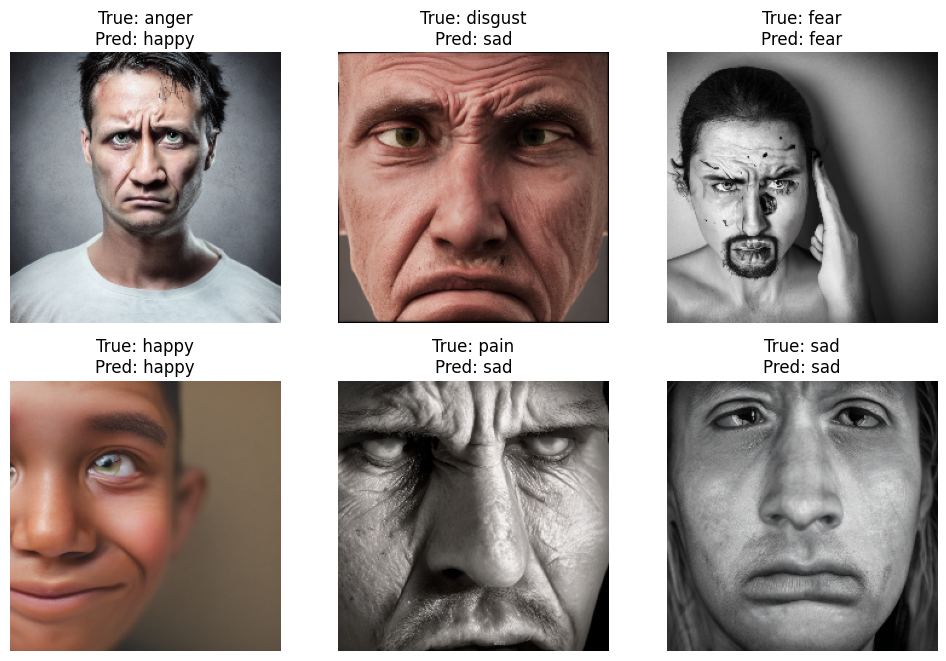

In [26]:
# visualization of prediction (transfer learning)
y_pred_probs = transfer_model.predict(X_synthetic)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_synthetic, axis=1)

# display 6 images
num_images = min(6, len(X_synthetic))

plt.figure(figsize=(10,10))
for i in range(num_images):
    plt.subplot(3,3,i+1)
    plt.imshow(X_synthetic[i])
    plt.title(f"True: {emotion_labels[y_true[i]]}\nPred: {emotion_labels[y_pred[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


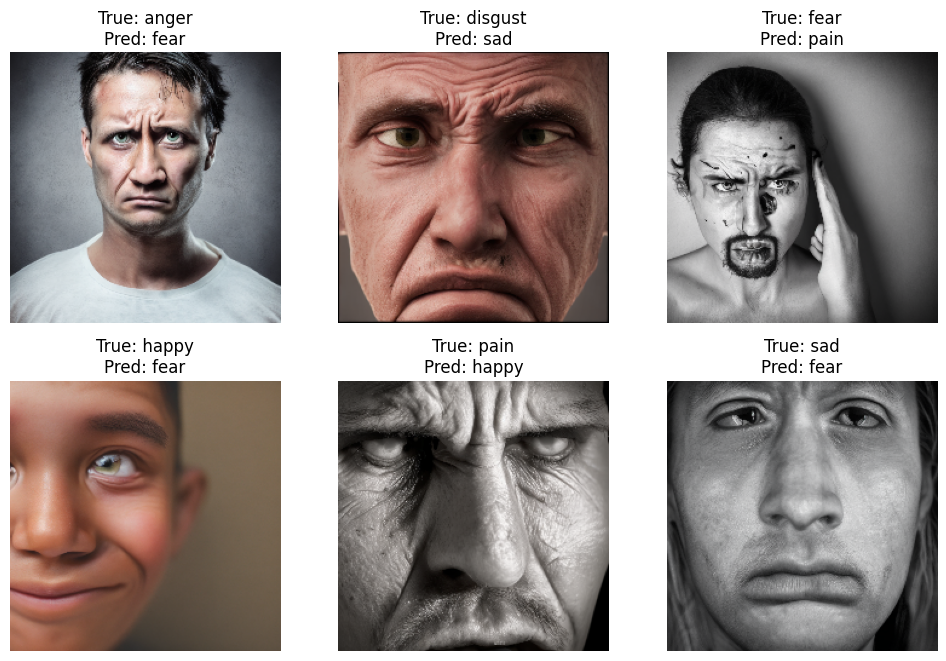

In [34]:
# visualization of prediction (custom cnn learning)
y_pred_probs = cnn_model.predict(X_synthetic)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_synthetic, axis=1)

# display 6 images
num_images = min(9, len(X_synthetic))

plt.figure(figsize=(10,10))
for i in range(num_images):
    plt.subplot(3,3,i+1)
    plt.imshow(X_synthetic[i])
    plt.title(f"True: {emotion_labels[y_true[i]]}\nPred: {emotion_labels[y_pred[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# unfreeze the trained model
cnn_model.trainable = False
transfer_model.trainable = False

In [29]:
# mix model performance
# identify parameter
input_layer = Input(shape=(224, 224, 3))

# prediction probability
pred_cnn = cnn_model(input_layer)
pred_transfer = transfer_model(input_layer)

# combine outputs (average probabilities)
combined_output = Average()([pred_cnn, pred_transfer])

mix_model = Model(inputs=input_layer, outputs=combined_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step


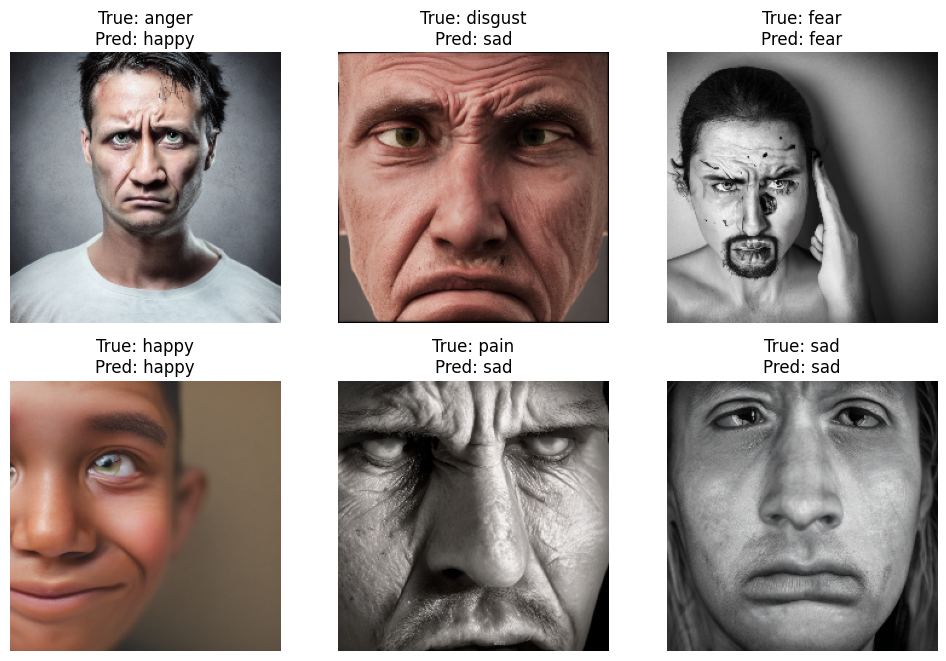

In [30]:
# predict with mixed model
y_pred_probs = mix_model.predict(X_synthetic)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_synthetic, axis=1)

# display 6 images
num_images = min(9, len(X_synthetic))

plt.figure(figsize=(10,10))
for i in range(num_images):
    plt.subplot(3,3,i+1)
    plt.imshow(X_synthetic[i])
    plt.title(f"True: {emotion_labels[y_true[i]]}\nPred: {emotion_labels[y_pred[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


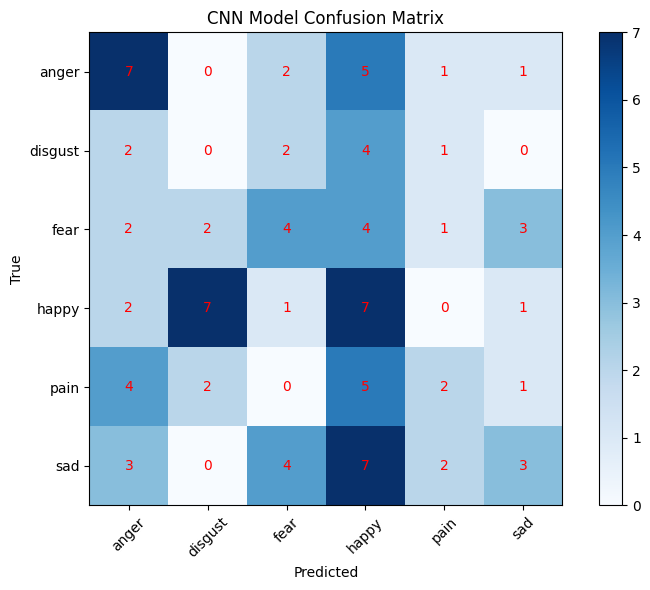

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


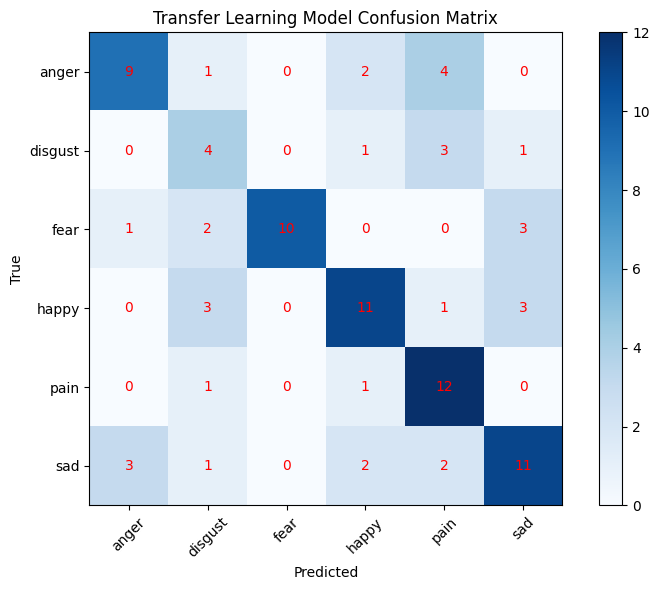

In [31]:
# confusion matrix for cnn model and transfer learning model
def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8,6))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='red')
    
    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45)
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.tight_layout()
    plt.show()

# custom cnn model predictions
y_pred_cnn = np.argmax(cnn_model.predict(cnn_X_test), axis=1)
y_true_cnn = np.argmax(cnn_y_test, axis=1)
plot_confusion_matrix(y_true_cnn, y_pred_cnn, emotion_labels, title="CNN Model Confusion Matrix")

# transfer learning model predictions
y_pred_tl = np.argmax(transfer_model.predict(cnn_X_test), axis=1)
y_true_tl = np.argmax(cnn_y_test, axis=1)
plot_confusion_matrix(y_true_tl, y_pred_tl, emotion_labels, title="Transfer Learning Model Confusion Matrix")